In [1]:
#Spark Session created:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("InstacartReorderPrediction") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()




In [2]:
#Get the data:
df_orders = spark.read.csv(path= "/home/jovyan/data/orders.csv", header= True, inferSchema= True)
df_prior = spark.read.csv(path="/home/jovyan/data/order_products__prior.csv", header= True, inferSchema= True)
df_train = spark.read.csv(path="/home/jovyan/data/order_products__train.csv", header= True, inferSchema= True)
df_products = spark.read.csv(path="/home/jovyan/data/products.csv", header= True, inferSchema= True)
df_aisles = spark.read.csv(path="/home/jovyan/data/aisles.csv", header= True, inferSchema= True)
df_departments = spark.read.csv(path="/home/jovyan/data/departments.csv", header= True, inferSchema= True)

df_orders.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: integer (nullable = true)
 |-- order_hour_of_day: integer (nullable = true)
 |-- days_since_prior_order: double (nullable = true)



In [3]:
print(f'order: {df_orders.printSchema()}')
print(f'aisles: {df_aisles.printSchema()}')
print(f'department: {df_departments.printSchema()}')
print(f'product: {df_products.printSchema()}')
print(f'train: {df_train.printSchema()}')
print(f'prior: {df_prior.printSchema()}')


root
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: integer (nullable = true)
 |-- order_hour_of_day: integer (nullable = true)
 |-- days_since_prior_order: double (nullable = true)

order: None
root
 |-- aisle_id: integer (nullable = true)
 |-- aisle: string (nullable = true)

aisles: None
root
 |-- department_id: integer (nullable = true)
 |-- department: string (nullable = true)

department: None
root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: string (nullable = true)
 |-- department_id: string (nullable = true)

product: None
root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)

train: None
root
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (null

Department ID và aisles ID ở bảng product là string, còn ở bảng aisles và department lại là integer. Check các giá trị đầu bảng và đổi thành integer để dễ merge sau này:

In [4]:
from pyspark.sql.functions import col, count
df_departments.show()
df_aisles.show()

df_products = df_products.withColumn('department_id', col('department_id').cast('integer'))
df_products = df_products.withColumn('aisle_id', col('aisle_id').cast('integer'))

+-------------+---------------+
|department_id|     department|
+-------------+---------------+
|            1|         frozen|
|            2|          other|
|            3|         bakery|
|            4|        produce|
|            5|        alcohol|
|            6|  international|
|            7|      beverages|
|            8|           pets|
|            9|dry goods pasta|
|           10|           bulk|
|           11|  personal care|
|           12|   meat seafood|
|           13|         pantry|
|           14|      breakfast|
|           15|   canned goods|
|           16|     dairy eggs|
|           17|      household|
|           18|         babies|
|           19|         snacks|
|           20|           deli|
+-------------+---------------+
only showing top 20 rows

+--------+--------------------+
|aisle_id|               aisle|
+--------+--------------------+
|       1|prepared soups sa...|
|       2|   specialty cheeses|
|       3| energy granola bars|
|       4|    

Check shape của dữ liệu:

In [5]:
print(f'orders: {df_orders.count()}')
print(f'prior: {df_prior.count()}')
print(f'train: {df_train.count()}')
print(f'products: {df_products.count()}')

print(f'products: {df_products.columns}')

orders: 3421083
prior: 32434489
train: 1384617
products: 49688
products: ['product_id', 'product_name', 'aisle_id', 'department_id']


Statistics ban đầu:

In [6]:
df_orders.describe().show()

+-------+-----------------+------------------+--------+------------------+------------------+-----------------+----------------------+
|summary|         order_id|           user_id|eval_set|      order_number|         order_dow|order_hour_of_day|days_since_prior_order|
+-------+-----------------+------------------+--------+------------------+------------------+-----------------+----------------------+
|  count|          3421083|           3421083| 3421083|           3421083|           3421083|          3421083|               3214874|
|   mean|        1710542.0|102978.20805926077|    NULL|17.154857979183785|2.7762191095626734|13.45201534134074|    11.114836226863012|
| stddev|987581.7398225836| 59533.71779350238|    NULL|17.733164470966738|2.0468291939879943| 4.22608840210201|      9.20673651753383|
|    min|                1|                 1|   prior|                 1|                 0|                0|                   0.0|
|    max|          3421083|            206209|   train|

In [7]:
df_prior.describe().show()

+-------+------------------+------------------+-----------------+-------------------+
|summary|          order_id|        product_id|add_to_cart_order|          reordered|
+-------+------------------+------------------+-----------------+-------------------+
|  count|          32434489|          32434489|         32434489|           32434489|
|   mean|1710748.5189427834|25576.337535424096|8.351075517175559| 0.5896974667922161|
| stddev| 987300.6964530181|14096.689090257141|7.126671161204413|0.49188857672327263|
|    min|                 2|                 1|                1|                  0|
|    max|           3421083|             49688|              145|                  1|
+-------+------------------+------------------+-----------------+-------------------+



In [8]:
df_products.describe().show()

+-------+------------------+--------------------+-----------------+------------------+
|summary|        product_id|        product_name|         aisle_id|     department_id|
+-------+------------------+--------------------+-----------------+------------------+
|  count|             49688|               49688|            49687|             49687|
|   mean|           24844.5|              1493.0|67.76919516171232|11.728580916537524|
| stddev|14343.834424588147|   620.4329133758138|38.31645086851397| 5.850420587359203|
|    min|                 1|"""Constant Comme...|                1|                 1|
|    max|             49688|with a Splash of ...|              134|                21|
+-------+------------------+--------------------+-----------------+------------------+



In [9]:
from pyspark.sql.functions import count, mean, countDistinct

df_orders.select(countDistinct('user_id')).show()
df_prior.agg(mean('reordered')).show()
df_orders.groupBy('user_id').agg(count('order_id').alias('order_count')) \
    .agg(mean('order_count')).show()
df_prior.groupBy('order_id').agg(count('product_id').alias('product_count')) \
    .agg(mean('product_count')).show()

+-----------------------+
|count(DISTINCT user_id)|
+-----------------------+
|                 206209|
+-----------------------+

+------------------+
|    avg(reordered)|
+------------------+
|0.5896974667922161|
+------------------+

+------------------+
|  avg(order_count)|
+------------------+
|16.590367054784224|
+------------------+

+------------------+
|avg(product_count)|
+------------------+
|10.088883421247614|
+------------------+



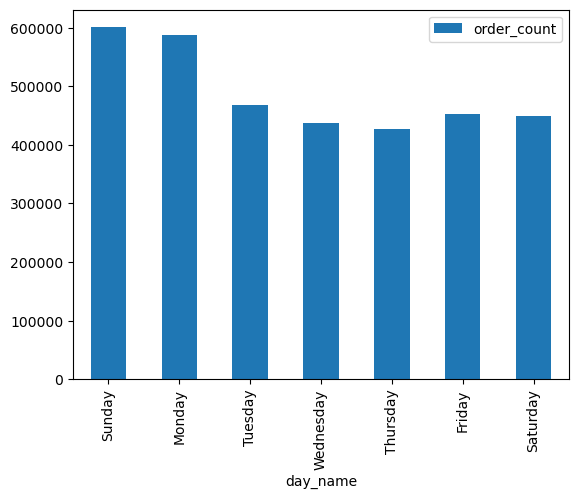

In [10]:


dow_counts = df_orders.groupBy('order_dow').agg(count('order_id').alias('order_count'))
dow_pd = dow_counts.toPandas().sort_values('order_dow')
day_names = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
dow_pd['day_name'] = dow_pd['order_dow'].map(lambda x: day_names[x])

import matplotlib.pyplot as plt
dow_pd.plot(kind='bar', x='day_name', y='order_count')
plt.show()

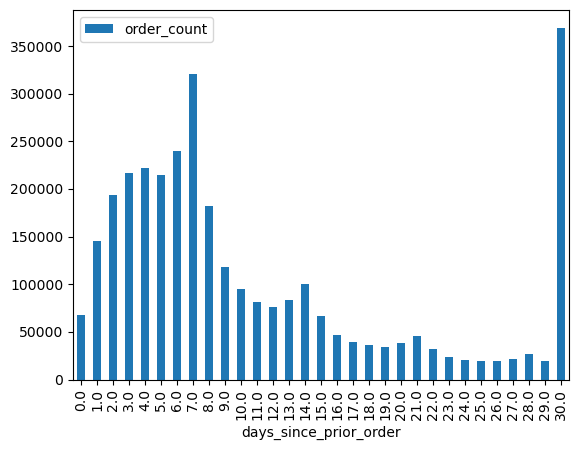

In [14]:
days_counts = df_orders.groupBy('days_since_prior_order') \
    .agg(count('order_id').alias('order_count'))
days_pd = days_counts.toPandas().sort_values('days_since_prior_order')
days_pd = days_pd.dropna(subset=['days_since_prior_order'])
days_pd.plot(kind='bar', x='days_since_prior_order', y='order_count')

plt.show()

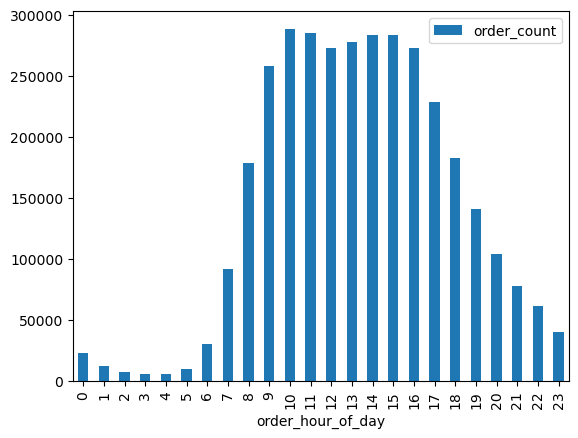

In [12]:

dow_counts = df_orders.groupBy('order_hour_of_day').agg(count('order_id').alias('order_count'))
dow_pd = dow_counts.toPandas().sort_values('order_hour_of_day')


import matplotlib.pyplot as plt
dow_pd.plot(kind='bar', x='order_hour_of_day', y='order_count')
plt.show()